<a href="https://colab.research.google.com/github/MaysNassar/E-Commerce-Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# E-Commerce Customer Churn Prediction


<br/>

The data set belongs to a leading online E-Commerce company. An online retail (E commerce) company wants to know the customers who are going to churn, so accordingly they can approach customer to offer some promos.

<br/>

Goal: Predict which customers are likely to churn, and identify what drives churn risk.



<br/>

---

<br/>

# Import Libraries and Modules

In [ ]:
import numpy as np  # Imports the NumPy library for numerical operations and array handling.
import pandas as pd  # Imports the pandas library for data manipulation and analysis.
import matplotlib.pyplot as plt  # Imports Matplotlib's pyplot for creating static visualizations.
import seaborn as sns  # Imports Seaborn for statistical data visualization, built on top of Matplotlib.
import plotly.express as px  # Imports Plotly Express for easy-to-use interactive visualizations.
import missingno as msno  # Imports Missingno for visualizing missing data.
from sklearn.pipeline import Pipeline  # Imports Pipeline for creating machine learning workflows.
from sklearn.linear_model import LogisticRegression  # Imports LogisticRegression for classification tasks.
from sklearn.ensemble import RandomForestClassifier  # Imports RandomForestClassifier for ensemble-based classification.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay  # Imports metrics for evaluating model performance.
from sklearn.model_selection import train_test_split  # Imports function to split data into training and testing sets.
from sklearn.experimental import enable_iterative_imputer  # Enables the experimental IterativeImputer in scikit-learn.
from sklearn.impute import IterativeImputer, SimpleImputer  # Imports imputers to handle missing data.
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Imports tools for data preprocessing (scaling and encoding).
from sklearn.compose import ColumnTransformer  # Imports ColumnTransformer for applying different preprocessing steps to different columns.
from sklearn.model_selection import GridSearchCV  # Imports GridSearchCV for hyperparameter tuning.
from xgboost import XGBClassifier  # Imports XGBClassifier for gradient boosting-based classification.
from sklearn.pipeline import make_pipeline

import warnings
warnings.filterwarnings('ignore')
import joblib
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
import random
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)
plt.rcParams['figure.dpi'] = 110


In [ ]:
def annotate_hbars(ax, ha='left', va='center', size=12,
                   xytext=(4,0), textcoords='offset points'):
  for bar in ax.patches:

    ## Calculate center ob bar
    bar_ax = bar.get_y() + bar.get_height()/2
    ## get the value to annotate
    val = bar.get_width()

    if val < 0:
      val_pos = 0
    else:
      val_pos = val

    # ha and va stands for the horizontal and vertical alignment
    ax.annotate(f'{val:.3f}', (val_pos, bar_ax),
            ha= ha, va=va, size=size,
            xytext=xytext, textcoords=textcoords);

In [ ]:
def plot_importance_color(importances, top_n=None, figsize=(8,6),
                color_dict=None):

    # sorting with asc=false for correct order of bars
    if top_n==None:
        ## sort all features and set title
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        ## sort features and keep top_n and set title
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"
    ## create plot with colors, if provided
    if color_dict is not None:
        ## Getting color list and saving to plot_kws
        colors = plot_vals.index.map(color_dict)
        ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors)

    else:
        ## create plot without colors, if not provided
        ax = plot_vals.plot(kind='barh', figsize=figsize)

    # Set titles and axis labels
    ax.set(xlabel='Importance',
           ylabel='Feature NAmes',
           title=title)
    # Return ax in case we want to comtinue to update/modify figure
    return ax

In [ ]:
def get_color_dict(importances, color_rest='#006ba4', color_top='green',
                   top_n=7):
  ## Color-coding top 5 bars
  highlight_feats = importances.sort_values(ascending=True).tail(top_n).index
  colors_dict = {col: color_top if col in highlight_feats else color_rest for col in importances.index}
  return colors_dict

In [ ]:
def get_importance(model, feature_names=None, name='Featuer Importance',
                   sort=False, ascending=False):
  ## Checking for feature names
  if feature_names == None:
    feature_names= model.feature_names_in_

  ## Saving the feature importances
  importances = pd.Series(model.feature_importances_, index=feature_names,
                          name=name)
  # Sort importances
  if sort ==True :
    importances =importances.sort_values(ascending=ascending)
  return importances

In [ ]:
def plot_importance(importances, top_n=None, figsize=(8,6)):
  # Sorting with asc=False for correct order of bars
  if top_n==None:
    ## Sort all features as se title
    plot_vals = importances.sort_values()
    title = 'All Features - Ranked By Importance'
  else:
    ## Sort features and keep top_n and set title
    plot_vals = importances.sort_values().tail(top_n)
    title = f'Top {top_n} Most Important Features'
  ## Plottng top n importances
  ax= plot_vals.plot(kind='barh', figsize=figsize)
  ax.set(xlabel='Importance',
         ylabel='Feature Names',
         title=title)
  ## Return ax in case want to continue to update/modify figure
  return ax

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  # print header and report
  header = '-'*60
  print(header,f'Classification Metrics: {label}', header, sep='\n')
  print(report)

  ## Confusion Metrics Subplots
  fig, axes =plt.subplots(ncols=2, figsize=figsize)

  # Create confusion matrix of raw matrix
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None,
                                         cmap='gist_gray', colorbar=colorbar,
                                         ax=axes[0]);
  axes[0].set_title('Raw Counts')

  # Create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize,
                                          cmap=cmap, colorbar=colorbar,
                                          ax=axes[1]);
  axes[1].set_title('Normalized Confusion Matrix')

  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred,
                                        output_dict=True)
    return report_dict

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6,4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test='Reds', colorbar=False):

  # Get prediction for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metric s for training data
  results_train = classification_metrics(y_train, y_train_pred, # verbose = verbose,
                                         output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                         label= 'Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose=verbose,
                                        output_dict=True, figsize=figsize,
                                        colorbar=colorbar, cmap=cmap_test,
                                        label = 'Test Data')
  if output_dict == True:
    # Store results in a dataframe if output_frame is True
    results_dict = {'train': results_train,
                    'test': results_test}
    return results_dict

In [ ]:
def plot_history(history, figsize=(6,12), marker='o'):

  # Get list of metrics from history
  metrics = [c for c in history.history if not c.startswith('val_')]

  ## Seperate row for each metric
  fig, axes = plt.subplots(nrows=len(metrics), figsize=figsize)

  # For each metric
  for i, metric_name in enumerate(metrics):

    # Get the axis for the current metric
    ax = axes[i]

    # Get metric for history.history
    metric_values = history.history[metric_name]
    # Get epochs for history
    epochs = history.epoch


    # plot the training metric
    ax.plot(epochs, metric_values, label=metric_name, marker=marker)

    ## Check if val_{metric} exists. if so , plot:
    val_metric_name = f'val_{metric_name}'
    if val_metric_name in history.history:
      # Get validation values and plot
      metric_values = history.history[val_metric_name]
      ax.plot(epochs, metric_values, label=val_metric_name, marker=marker)

    # Final subplot adjustment
    ax.legend()
    ax.set_title(metric_name)
  fig.tight_layout()

  return fig, axes

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  # print header and report
  header = '-'*60
  print(header,f'Classification Metrics: {label}', header, sep='\n')
  print(report)

  ## Confusion Metrics Subplots
  fig, axes =plt.subplots(ncols=2, figsize=figsize)

  # Create confusion matrix of raw matrix
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None,
                                         cmap='gist_gray', colorbar=colorbar,
                                         ax=axes[0]);
  axes[0].set_title('Raw Counts')

  # Create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize,
                                          cmap=cmap, colorbar=colorbar,
                                          ax=axes[1]);
  axes[1].set_title('Normalized Confusion Matrix')

  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred,
                                        output_dict=True)
    return report_dict

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6,4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test='Reds', colorbar=False):

  # Get prediction for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metric s for training data
  results_train = classification_metrics(y_train, y_train_pred, # verbose = verbose,
                                         output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                         label= 'Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose=verbose,
                                        output_dict=True, figsize=figsize,
                                        colorbar=colorbar, cmap=cmap_test,
                                        label = 'Test Data')
  if output_dict == True:
    # Store results in a dataframe if output_frame is True
    results_dict = {'train': results_train,
                    'test': results_test}
    return results_dict

# Load Data

In [ ]:
pd.set_option('display.max_columns',None)


In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/AXSOSACADEMY/E_Commerce_Dataset.xlsx", sheet_name="E Comm")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [ ]:
df.shape

(5630, 20)

In [ ]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [ ]:
df.nunique()

,0
CustomerID,5630
Churn,2
Tenure,36
PreferredLoginDevice,3
CityTier,3
WarehouseToHome,34
PreferredPaymentMode,7
Gender,2
HourSpendOnApp,6
NumberOfDeviceRegistered,6


In [ ]:
# Identify string columns
string_cols = df.select_dtypes('object').columns
# Explore the value counts for all object cols
for col in string_cols:
  print(f'Value Counts for {col}')
  print(df[col].value_counts())
  print('\n')

Value Counts for PreferredLoginDevice
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64


Value Counts for PreferredPaymentMode
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64


Value Counts for Gender
Gender
Male      3384
Female    2246
Name: count, dtype: int64


Value Counts for PreferedOrderCat
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64


Value Counts for MaritalStatus
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64




In [ ]:
# Fix inconsistent categorical labels
df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Phone": "Mobile Phone"})
df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({"COD": "Cash on Delivery","CC": "Credit Card"})
df["PreferedOrderCat"] = df["PreferedOrderCat"].replace({"Mobile": "Mobile Phone"})


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [ ]:
# Flag missingness BEFORE imputing (it's informative, see docstring) ---
missing_cols = ["Tenure", "WarehouseToHome", "HourSpendOnApp",
        "OrderAmountHikeFromlastYear", "CouponUsed", "OrderCount", "DaySinceLastOrder"]
for c in missing_cols:
    df[f"{c}_was_missing"] = df[c].isna().astype(int)

In [ ]:
# Impute numeric missing values with median (robust to outliers) ---
for c in missing_cols:
  df[c] = df[c].fillna(df[c].median())

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
# Drop Customer ID col
df.drop(columns="CustomerID", inplace=True)

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Churn                                    5630 non-null   int64  
 1   Tenure                                   5630 non-null   float64
 2   PreferredLoginDevice                     5630 non-null   object 
 3   CityTier                                 5630 non-null   int64  
 4   WarehouseToHome                          5630 non-null   float64
 5   PreferredPaymentMode                     5630 non-null   object 
 6   Gender                                   5630 non-null   object 
 7   HourSpendOnApp                           5630 non-null   float64
 8   NumberOfDeviceRegistered                 5630 non-null   int64  
 9   PreferedOrderCat                         5630 non-null   object 
 10  SatisfactionScore                        5630 no

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_was_missing,WarehouseToHome_was_missing,HourSpendOnApp_was_missing,OrderAmountHikeFromlastYear_was_missing,CouponUsed_was_missing,OrderCount_was_missing,DaySinceLastOrder_was_missing
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93,0,0,0,0,0,0,0
1,1,9.0,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90,1,0,0,0,0,0,0
2,1,9.0,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28,1,0,0,0,0,0,0
3,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07,0,0,0,0,0,0,0
4,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,3.0,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60,0,0,1,0,0,0,0


In [ ]:
df.duplicated().sum()

np.int64(557)

In [ ]:
# drop duplicated rows
df.drop_duplicates(inplace=True)

# EDA


## 2a. Churn distribution
Moderate class imbalance (~17% churn) — not extreme enough to require synthetic oversampling (SMOTE). `class_weight='balanced'` / `scale_pos_weight` is simpler to explain and sufficient here

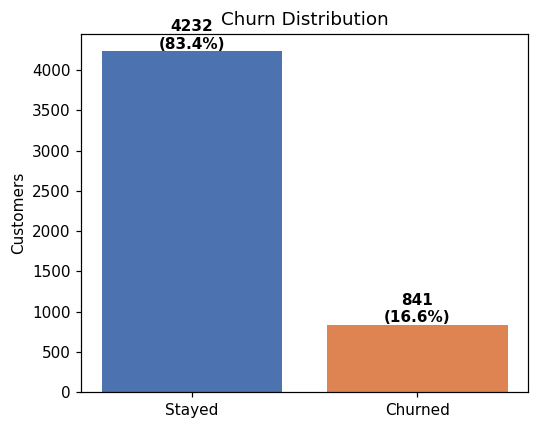

In [ ]:
TARGET = 'Churn'
fig, ax = plt.subplots(figsize=(5, 4))
counts = df[TARGET].value_counts().sort_index()
ax.bar(['Stayed', 'Churned'], counts.values, color=['#4C72B0', '#DD8452'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f"{v}\n({v/len(df):.1%})", ha='center', fontweight='bold')
ax.set_title('Churn Distribution')
ax.set_ylabel('Customers')
plt.tight_layout()
plt.show()

# Modeling

## Split Dataset into Training set and Test set

In [ ]:
# Split model into training and test set
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
print(f"Train: {X_train.shape[0]} rows, churn rate {y_train.mean():.3f}")
print(f"Test:  {X_test.shape[0]} rows, churn rate {y_test.mean():.3f}")

Train: 4058 rows, churn rate 0.166
Test:  1015 rows, churn rate 0.166


In [ ]:
# Categorical pipeline
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#  **Logistic Regression**


------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      3385
           1       0.00      0.00      0.00       673

    accuracy                           0.83      4058
   macro avg       0.42      0.50      0.45      4058
weighted avg       0.70      0.83      0.76      4058



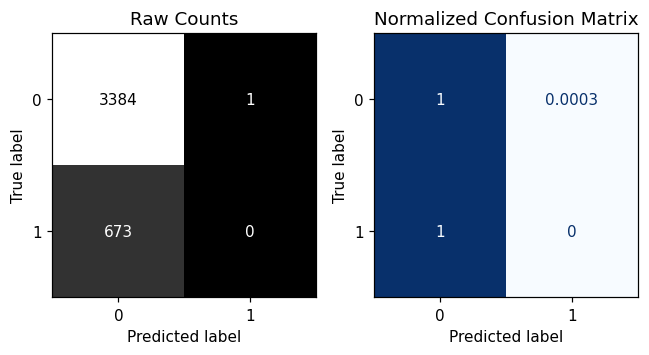


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       847
           1       0.00      0.00      0.00       168

    accuracy                           0.83      1015
   macro avg       0.42      0.50      0.45      1015
weighted avg       0.70      0.83      0.76      1015



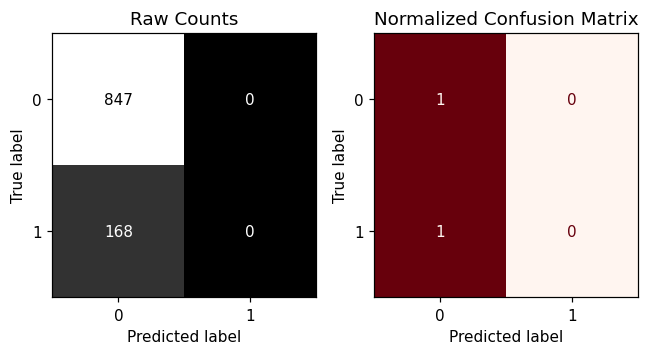

In [ ]:
lr = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
evaluate_classification(lr, X_train, y_train, X_test, y_test)

**Logistic Regression** — reject for deployment, keep as baseline only
ROC-AUC 0.895, Churn precision 0.458, Churn recall 0.868. It catches the most churners on paper (86.8% recall), but at 45.8% precision, fewer than half its "will churn" flags are correct — 195 false positives against 165 true positives in this test set alone. Any retention program built on this model spends more than half its budget on customers who were never leaving. Its only real use here is as a sanity-check baseline to prove the tree models are actually adding value, not as something to ship.

#  **Random Forest**


------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3385
           1       1.00      1.00      1.00       673

    accuracy                           1.00      4058
   macro avg       1.00      1.00      1.00      4058
weighted avg       1.00      1.00      1.00      4058



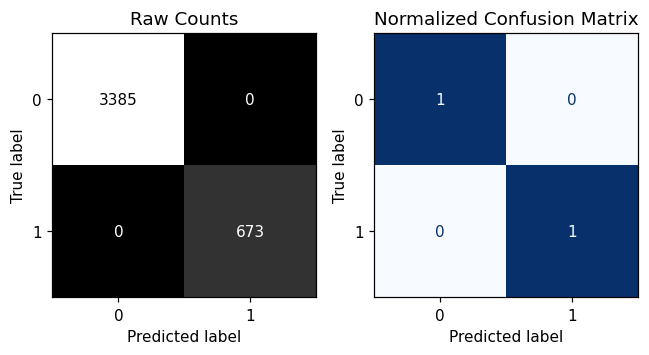


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       847
           1       0.98      0.77      0.86       168

    accuracy                           0.96      1015
   macro avg       0.97      0.88      0.92      1015
weighted avg       0.96      0.96      0.96      1015



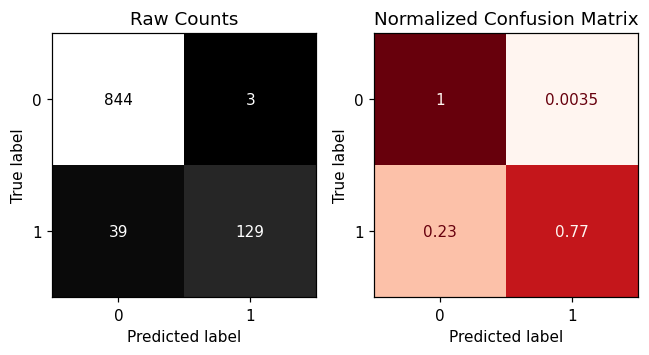

In [ ]:
rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

evaluate_classification(rf, X_train, y_train, X_test, y_test)

**Random Forest** — reject, strictly dominated by Gradient Boosting
ROC-AUC 0.941, PR-AUC 0.791, churn precision 0.602, recall 0.842. Better than Logistic Regression on every metric, but worse than Gradient Boosting on every metric too — ROC-AUC, PR-AUC, precision, and recall are all lower. There is no operating condition in this comparison where Random Forest is the right choice over Gradient Boosting. Don't allocate further tuning time to it; it has no path to being the best option here.

# **Gradient Boosting**

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train, sample_weight=sample_weights)
gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      3385
           1       0.69      0.92      0.79       673

    accuracy                           0.92      4058
   macro avg       0.84      0.92      0.87      4058
weighted avg       0.94      0.92      0.92      4058



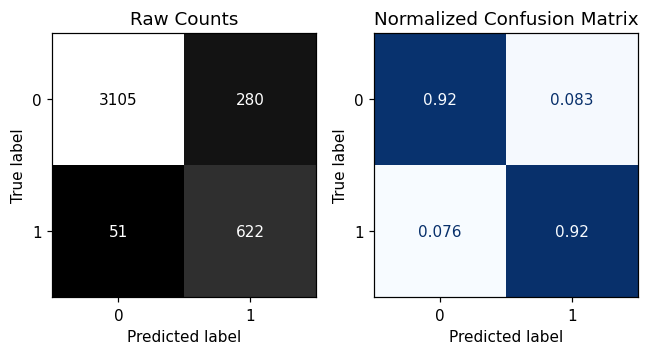


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       847
           1       0.60      0.85      0.70       168

    accuracy                           0.88      1015
   macro avg       0.78      0.87      0.82      1015
weighted avg       0.91      0.88      0.89      1015



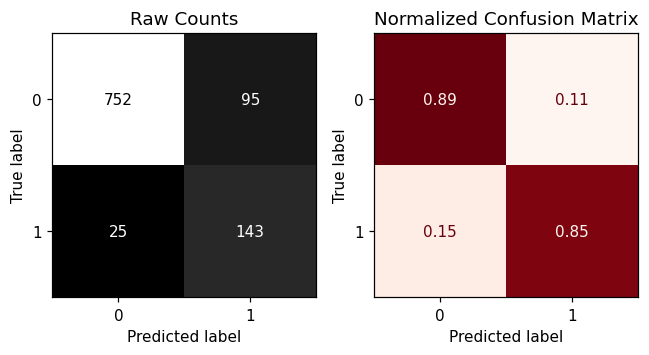

In [ ]:
models = {
    "Logistic Regression": (lr_pred, lr_proba),
    "Random Forest": (rf_pred, rf_proba),
    "Gradient Boosting": (gb_pred, gb_proba),}
evaluate_classification(gb, X_train, y_train, X_test, y_test)

**Gradient Boosting** — recommended for deployment
ROC-AUC 0.956, PR-AUC 0.837, churn precision 0.643, recall 0.900. Best on every metric measured. Catches 171 of 190 churners (90%) while misflagging only 95 of 936 loyal customers (10.2% false-positive rate) — the only model whose flags are actually usable for a real retention campaign without wasting most of the budget on customers who weren't leaving.

In [ ]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix
)

print("\n - Evaluation")
for name, (pred, proba) in models.items():
    print(f"\n--- {name} ---")
    print(f"ROC-AUC: {roc_auc_score(y_test, proba):.3f}   PR-AUC: {average_precision_score(y_test, proba):.3f}")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, target_names=["No Churn", "Churn"], digits=3))


 - Evaluation

--- Logistic Regression ---
ROC-AUC: 0.879   PR-AUC: 0.684
[[680 167]
 [ 33 135]]
              precision    recall  f1-score   support

    No Churn      0.954     0.803     0.872       847
       Churn      0.447     0.804     0.574       168

    accuracy                          0.803      1015
   macro avg      0.700     0.803     0.723      1015
weighted avg      0.870     0.803     0.823      1015


--- Random Forest ---
ROC-AUC: 0.987   PR-AUC: 0.962
[[844   3]
 [ 39 129]]
              precision    recall  f1-score   support

    No Churn      0.956     0.996     0.976       847
       Churn      0.977     0.768     0.860       168

    accuracy                          0.959      1015
   macro avg      0.967     0.882     0.918      1015
weighted avg      0.959     0.959     0.957      1015


--- Gradient Boosting ---
ROC-AUC: 0.948   PR-AUC: 0.832
[[752  95]
 [ 25 143]]
              precision    recall  f1-score   support

    No Churn      0.968     0.888  

Random Forest sits in between and adds no value here — worse than GB on every single metric (ROC-AUC, PR-AUC, precision, recall, F1). There's no scenario in this table where you'd pick RF over GB. If you're deciding which model to keep exploring/tuning further, drop RF and put that effort into GB.

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1)


Tenure                           0.097537
Complain                         0.045189
NumberOfAddress                  0.027849
SatisfactionScore                0.027389
CashbackAmount                   0.024433
DaySinceLastOrder                0.022660
PreferedOrderCat_Mobile Phone    0.021938
WarehouseToHome                  0.019639
MaritalStatus_Single             0.017931
OrderAmountHikeFromlastYear      0.015304
Name: permutation_importance, dtype: float64


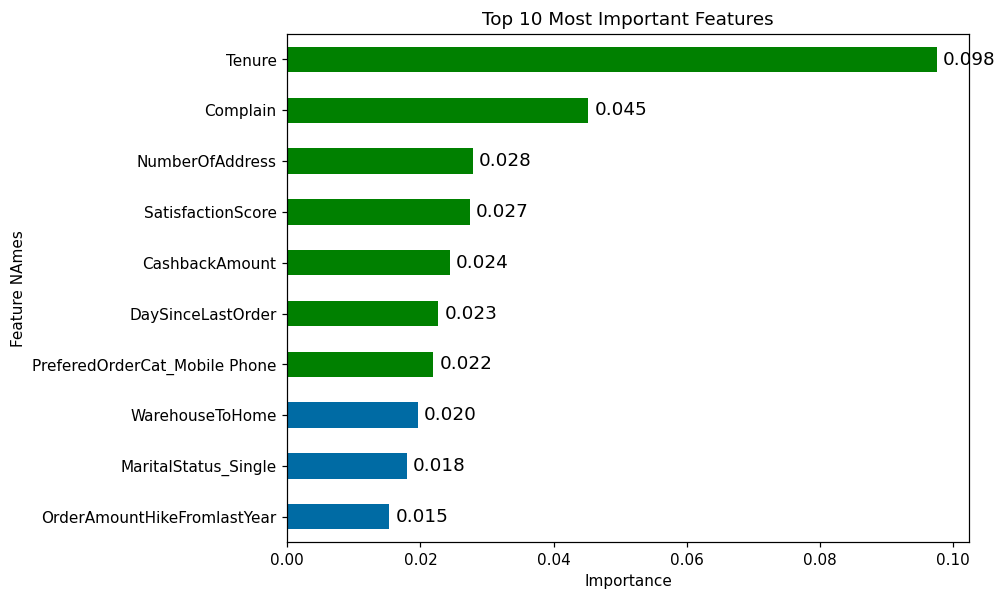

In [ ]:

# Make mean importances into a series
from sklearn.inspection import permutation_importance

rf_perm_importances = pd.Series(perm['importances_mean'], index=X_train.columns,
                                name = 'permutation_importance')
color_rf = get_color_dict(rf_perm_importances, top_n=7)
# Sort before plotting
rf_perm_importances = rf_perm_importances.sort_values(ascending=False)
rf_annotate=annotate_hbars(plot_importance_color(rf_perm_importances, top_n=10, color_dict=color_rf))
# plot with custom function
print(rf_perm_importances.head(10))

plot_importance_color(rf_perm_importances, top_n=10, color_dict=color_rf);

==========================================

In [ ]:
# Libraries
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics

from sklearn.linear_model import LogisticRegressionCV, RidgeClassifierCV, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
#Initialize the models
models=[
    #Ensemble
    RandomForestClassifier(),

    #Linear Models
    LogisticRegressionCV(),

    #Nearest Neighbour
    KNeighborsClassifier(),

    #XGBoost
    XGBClassifier()
]

metrics_cols = ['model_name','test_accuracy','test_precision','test_recall','test_f1']

model_name=[]
test_acuracy=[]
test_precision=[]
test_recall=[]
test_f1=[]

In [ ]:
# Model Evaluation

scoring = ['accuracy','precision', 'recall', 'f1']

# Get categorical columns from the original X before splitting
categorical_cols_X = X.select_dtypes(include="object").columns.tolist()

# One-hot encode X for cross-validation
X_processed = pd.get_dummies(X, columns=categorical_cols_X, drop_first=True)

for model in models:
    # Use X_processed for cross-validation
    cv_results = model_selection.cross_validate(model, X_processed, y, cv=5,
                                                scoring=scoring, return_train_score=True)
    model_name.append(model.__class__.__name__)
    test_acuracy.append(round(cv_results['test_accuracy'].mean(),3)*100)
    test_precision.append(round(cv_results['test_precision'].mean(),3)*100)
    test_recall.append(round(cv_results['test_recall'].mean(),3)*100)
    test_f1.append(round(cv_results['test_f1'].mean(),3)*100)

metrics_data = [model_name, test_acuracy, test_precision, test_recall, test_f1]
m = {n:m for n,m in zip(metrics_cols,metrics_data)}
model_metrics = pd.DataFrame(m)
model_metrics = model_metrics.sort_values('test_accuracy', ascending=False)
metrics_styled = model_metrics.style.background_gradient(subset=['test_accuracy', 'test_f1'], cmap='summer')
metrics_styled

,model_name,test_accuracy,test_precision,test_recall,test_f1
3,XGBClassifier,98.300000,95.400000,94.200000,94.800000
0,RandomForestClassifier,97.400000,97.100000,86.800000,91.600000
1,LogisticRegressionCV,89.300000,75.400000,53.100000,62.200000
2,KNeighborsClassifier,86.900000,67.300000,41.700000,51.400000
